In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Define the base directory where your folders are located
base_dir = 'Alzheimer_s Dataset'

# List of folder names (these will be the target labels)
folders = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Prepare lists to hold data
image_paths = []
image_arrays = []
targets = []
image_size = (128, 128)
# Loop through each folder
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    
    # Loop through each image in the folder
    for img_name in os.listdir(folder_path):
        # Get the full image path
        img_path = os.path.join(folder_path, img_name)
        
        # Read the image using OpenCV
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Convert the image from BGR (OpenCV default) to RGB (optional, depending on your use case)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, image_size)
        # Append the path, image array, and target label (folder name)
        image_paths.append(img_path)
        image_arrays.append(img_resized)
        targets.append(folder)

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'image_array': image_arrays,
    'target': targets
})

# Display the DataFrame
df.head()


,image_path,image_array,target
0,Alzheimer_s Dataset\MildDemented\26 (19).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
1,Alzheimer_s Dataset\MildDemented\26 (20).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
2,Alzheimer_s Dataset\MildDemented\26 (21).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
3,Alzheimer_s Dataset\MildDemented\26 (22).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented
4,Alzheimer_s Dataset\MildDemented\26 (23).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",MildDemented


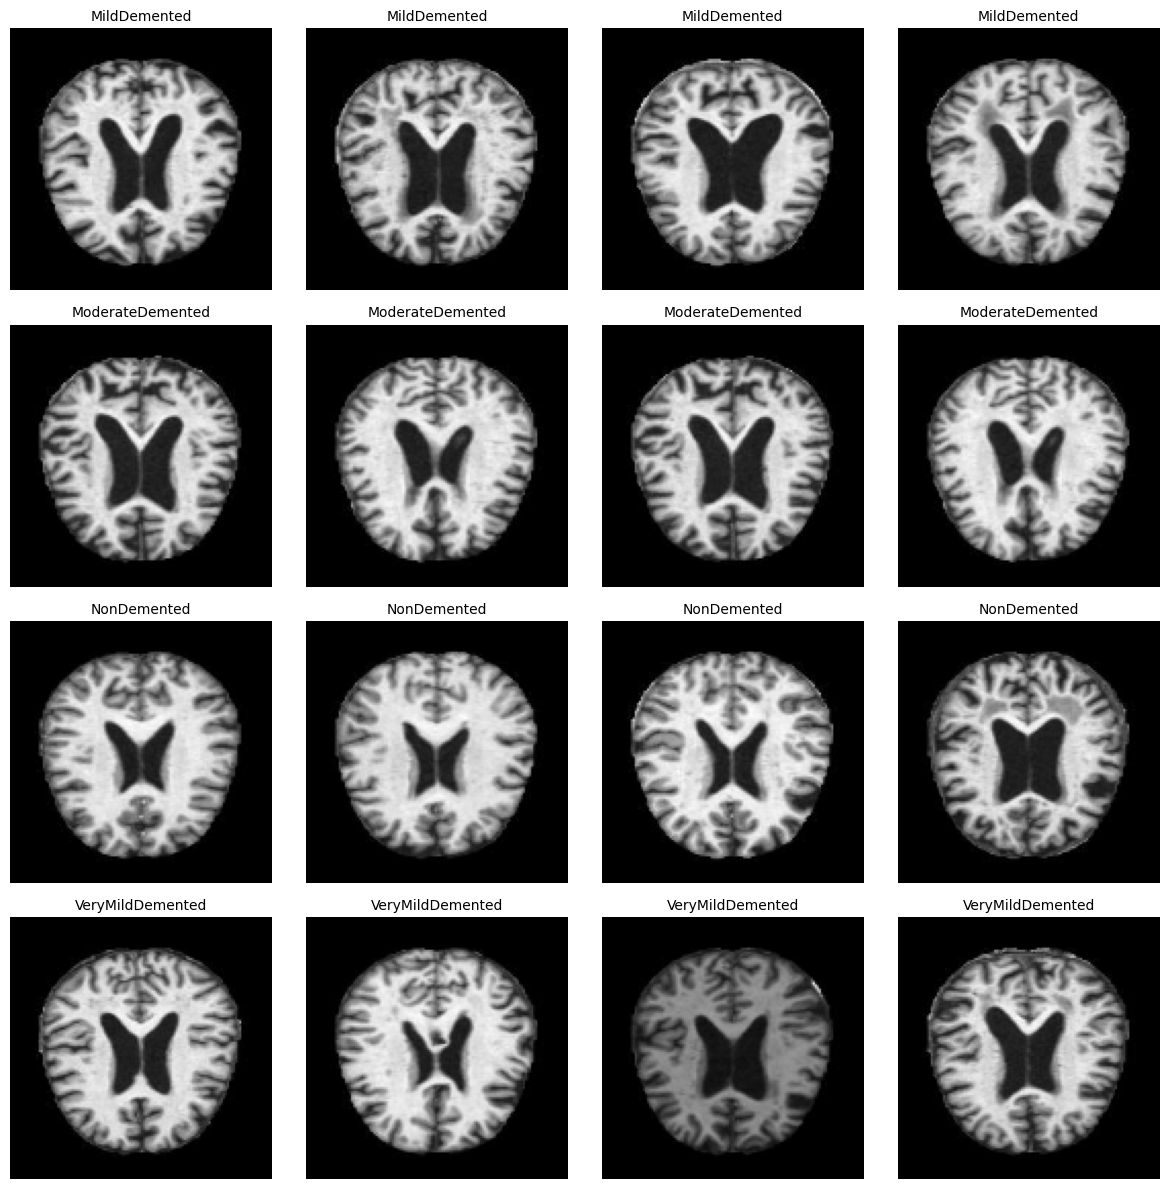

In [3]:
import matplotlib.pyplot as plt

# Number of images to display for each target
num_images = 4

# Set up the plot grid
fig, axs = plt.subplots(len(folders), num_images, figsize=(12, 12))

# Loop through each target (folder name)
for i, folder in enumerate(folders):
    # Get the first 4 images for the current target label
    target_images = df[df['target'] == folder]['image_array'].head(num_images)
    
    # Plot 4 images in the row corresponding to the current target
    for j, img_array in enumerate(target_images):
        # Display the image
        axs[i, j].imshow(img_array)
        axs[i, j].axis('off')  # Hide the axis for a cleaner display
        axs[i, j].set_title(f'{folder}', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [4]:
dict_c = {'MildDemented':0, 'ModerateDemented':1, 'NonDemented':2, 'VeryMildDemented':3}
df['target'] = df['target'].map(dict_c)
df.tail()

,image_path,image_array,target
6395,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6396,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6397,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6398,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3
6399,Alzheimer_s Dataset\VeryMildDemented\verymildD...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",3


In [5]:
df.head()

,image_path,image_array,target
0,Alzheimer_s Dataset\MildDemented\26 (19).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
1,Alzheimer_s Dataset\MildDemented\26 (20).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
2,Alzheimer_s Dataset\MildDemented\26 (21).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
3,Alzheimer_s Dataset\MildDemented\26 (22).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0
4,Alzheimer_s Dataset\MildDemented\26 (23).jpg,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",0


In [6]:
# Convert image arrays and targets to NumPy arrays
X = np.array(df['image_array'].tolist())  # Convert list of arrays to a 4D NumPy array
y = np.array(df.target)       # Labels

# Normalize image data (scale pixel values to 0-1)
X = X / 255.0

In [7]:
from tensorflow.keras.utils import to_categorical

# Convert targets to one-hot encoding
y_categorical = to_categorical(y, num_classes=len(dict_c))

In [9]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(dict_c), activation='softmax')  # Number of output classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [11]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 43s 241ms/step - accuracy: 0.4602 - loss: 1.1124 - val_accuracy: 0.4375 - val_loss: 1.1291
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 36s 224ms/step - accuracy: 0.4951 - loss: 0.9978 - val_accuracy: 0.5852 - val_loss: 0.9620
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 35s 219ms/step - accuracy: 0.5572 - loss: 0.9297 - val_accuracy: 0.5914 - val_loss: 0.8120
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 250ms/step - accuracy: 0.5944 - loss: 0.8444 - val_accuracy: 0.6336 - val_loss: 0.7599
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 62s 388ms/step - accuracy: 0.6401 - loss: 0.7691 - val_accuracy: 0.6562 - val_loss: 0.7131
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 254ms/step - accuracy: 0.6753 - loss: 0.6875 - val_accuracy: 0.7375 - val_loss: 0.5881
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 38s 238ms/step - accuracy: 0.7275 - loss: 0.6008 - val_accuracy: 0.7844 - val_loss: 0.5393
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 37s 230ms/step - accuracy: 0.7593 - loss: 0

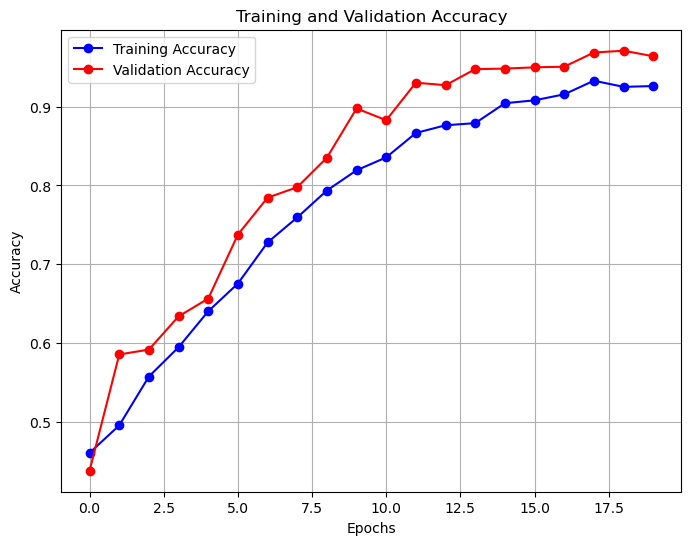

In [16]:
import matplotlib.pyplot as plt

# Data
train_accuracy = [0.4602, 0.4951, 0.5572, 0.5944, 0.6401, 0.6753, 0.7275, 0.7593, 0.7935, 0.8192, 0.8356, 0.8666, 0.8764, 0.8791, 0.9044, 0.9081, 0.9157, 0.9330, 0.9252, 0.9262]
val_accuracy = [0.4375, 0.5852, 0.5914, 0.6336, 0.6562, 0.7375, 0.7844, 0.7977, 0.8352, 0.8977, 0.8828, 0.9305, 0.9273, 0.9477, 0.9484, 0.9500, 0.9508, 0.9688, 0.9711, 0.9641]

# Plotting accuracy
plt.figure(figsize=(8, 6))

plt.plot(train_accuracy, label='Training Accuracy', color='b',marker = 'o')
plt.plot(val_accuracy, label='Validation Accuracy', color='r',marker = 'o')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.grid(True)
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


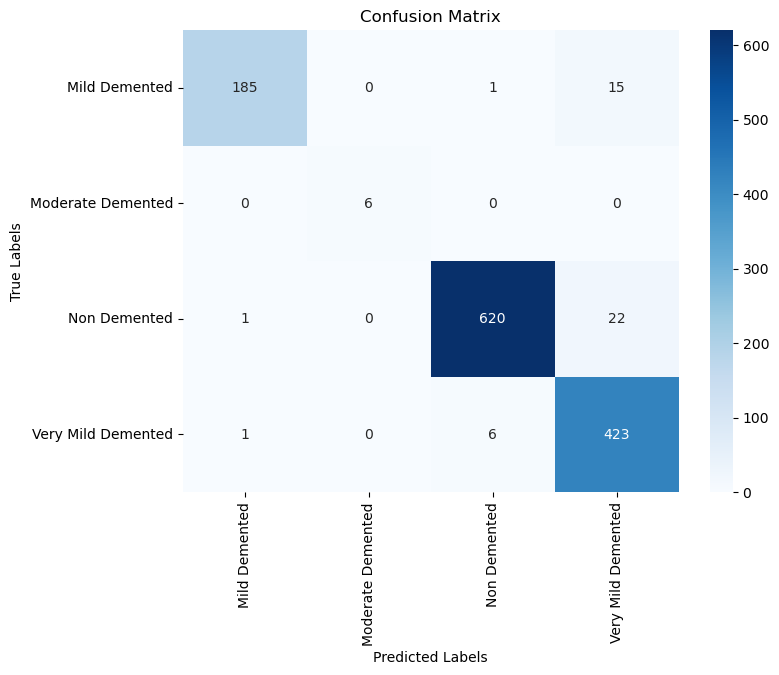

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.99      0.92      0.95       201
 Moderate Demented       1.00      1.00      1.00         6
      Non Demented       0.99      0.96      0.98       643
Very Mild Demented       0.92      0.98      0.95       430

          accuracy                           0.96      1280
         macro avg       0.97      0.97      0.97      1280
      weighted avg       0.97      0.96      0.96      1280



In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]


# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


In [15]:
import cv2  # OpenCV for image resizing
import numpy as np

# Resize the images to 224x224x3
def resize_images(X):
    resized_images = []
    for img in X:
        resized_img = cv2.resize(img, (224, 224))  # Resize to 224x224
        resized_images.append(resized_img)
    return np.array(resized_images)

# Resize your training and testing data
X_train_resized = resize_images(X_train)
X_test_resized = resize_images(X_test)


In [16]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Assume X contains image data and y contains labels
# Preprocessing the data
y_encoded = LabelEncoder().fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Load ResNet50 with pre-trained weights, exclude the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the base model
base_model.trainable = False

# Add custom layers for the task
x = base_model.output
x = Flatten()(x)  # Flatten the output
x = Dense(256, activation='relu')(x)  # Fully connected layer
x = Dense(y_categorical.shape[1], activation='softmax')(x)  # Output layer

# Create the model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train_resized, y_train,
    validation_data=(X_test_resized, y_test),
    epochs=20,
    batch_size=32
)

# Evaluate the model
results = model.evaluate(X_test_resized, y_test, batch_size=32)
print(f"Test Accuracy: {results[1]}")


Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.4404 - loss: 1.3107 - val_accuracy: 0.5023 - val_loss: 1.0833
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.5274 - loss: 0.9927 - val_accuracy: 0.5742 - val_loss: 1.0360
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.5300 - loss: 0.9915 - val_accuracy: 0.5195 - val_loss: 1.0409
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.5606 - loss: 0.9286 - val_accuracy: 0.4437 - val_loss: 1.0454
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.5664 - loss: 0.9148 - val_accuracy: 0.5992 - val_loss: 0.8392
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.5959 - loss: 0.8730 - val_accuracy: 0.5437 - val_loss: 0.8532
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.5811 - loss: 0.9017 - val_accuracy: 0.5797 - val_loss: 0.8825
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.6118 - loss: 0.8601 - val_accu

InvalidArgumentError: Graph execution error:

Detected at node functional_2_1/dense_4_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>

  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start

  File "C:\ProgramData\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "C:\ProgramData\anaconda3\Lib\asyncio\windows_events.py", line 322, in run_forever

  File "C:\ProgramData\anaconda3\Lib\asyncio\base_events.py", line 641, in run_forever

  File "C:\ProgramData\anaconda3\Lib\asyncio\base_events.py", line 1987, in _run_once

  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 88, in _run

  File "C:\Pr

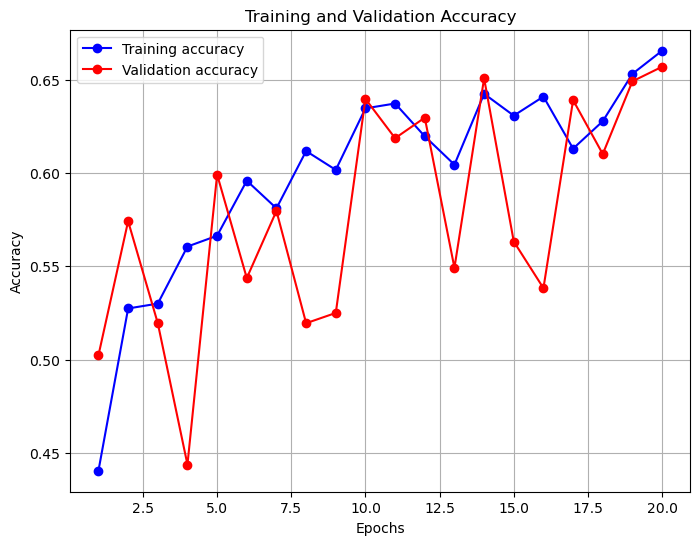

In [15]:
import matplotlib.pyplot as plt

# Extracted data from the logs
epochs = list(range(1, 21))
accuracy = [
    0.4404, 0.5274, 0.5300, 0.5606, 0.5664, 0.5959, 0.5811, 0.6118, 0.6017,
    0.6347, 0.6373, 0.6197, 0.6045, 0.6425, 0.6308, 0.6410, 0.6131, 0.6278, 
    0.6532, 0.6656
]
val_accuracy = [
    0.5023, 0.5742, 0.5195, 0.4437, 0.5992, 0.5437, 0.5797, 0.5195, 0.5250, 
    0.6398, 0.6187, 0.6297, 0.5492, 0.6508, 0.5633, 0.5383, 0.6391, 0.6102, 
    0.6492, 0.6570
]

# Plotting the training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, accuracy, 'b', label='Training accuracy',marker = 'o')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy',marker = 'o')

# Adding titles and labels
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


In [19]:
# Evaluate the model
results = model.evaluate(X_test_resized, y_test, batch_size=32)
print(f"Test Accuracy: {results[1]}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.6457 - loss: 0.7711
Test Accuracy: 0.657031238079071


40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step


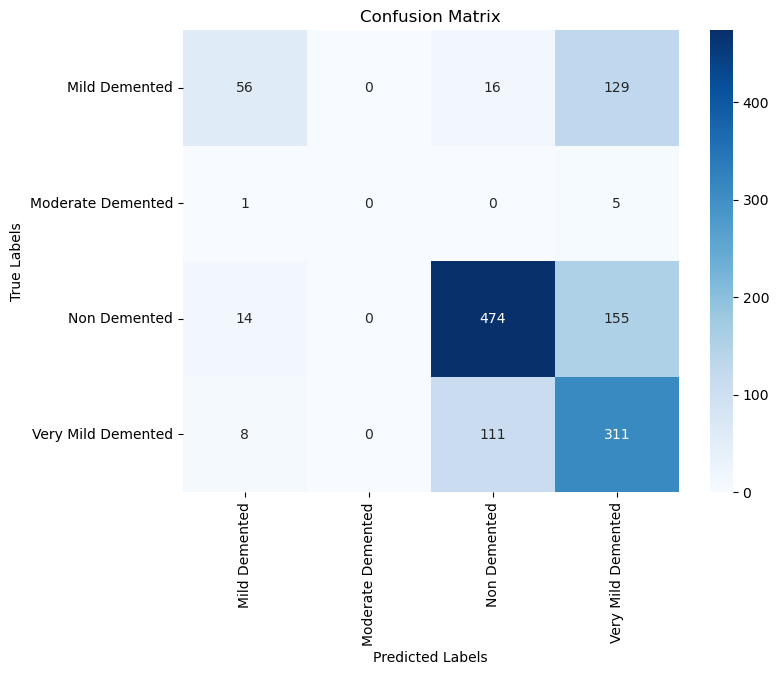

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.71      0.28      0.40       201
 Moderate Demented       0.00      0.00      0.00         6
      Non Demented       0.79      0.74      0.76       643
Very Mild Demented       0.52      0.72      0.60       430

          accuracy                           0.66      1280
         macro avg       0.50      0.43      0.44      1280
      weighted avg       0.68      0.66      0.65      1280



In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test_resized)  # X_test should already be resized to (224, 224, 3)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


In [22]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Assume X contains image data and y contains labels
# Preprocessing the data
y_encoded = LabelEncoder().fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Load InceptionV3 with pre-trained ImageNet weights, exclude the top layer (classification layer)
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the layers of the base model (you can unfreeze some layers for fine-tuning)
base_model.trainable = False

# Add custom layers on top of InceptionV3
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  # Global Average Pooling layer
x = layers.Dense(1024, activation='relu')(x)  # Fully connected layer
x = layers.Dropout(0.5)(x)  # Dropout layer to prevent overfitting
x = layers.Dense(y_categorical.shape[1], activation='softmax')(x)  # Output layer

# Create the final model
model = models.Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

# Evaluate the model
results = model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Accuracy: {results[1]}")


Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 77s 362ms/step - accuracy: 0.4625 - loss: 1.8122 - val_accuracy: 0.5844 - val_loss: 0.8925
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 54s 335ms/step - accuracy: 0.5648 - loss: 0.9721 - val_accuracy: 0.6023 - val_loss: 0.8275
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 56s 353ms/step - accuracy: 0.6091 - loss: 0.8694 - val_accuracy: 0.5992 - val_loss: 0.8266
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 59s 368ms/step - accuracy: 0.6176 - loss: 0.8197 - val_accuracy: 0.6359 - val_loss: 0.7883
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 60s 377ms/step - accuracy: 0.6419 - loss: 0.7820 - val_accuracy: 0.6313 - val_loss: 0.8082
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 63s 391ms/step - accuracy: 0.6470 - loss: 0.7758 - val_accuracy: 0.6539 - val_loss: 0.7434
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 60s 376ms/step - accuracy: 0.6540 - loss: 0.7488 - val_accuracy: 0.6828 - val_loss: 0.7153
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 60s 378ms/step - accuracy: 0.6953 - loss: 0

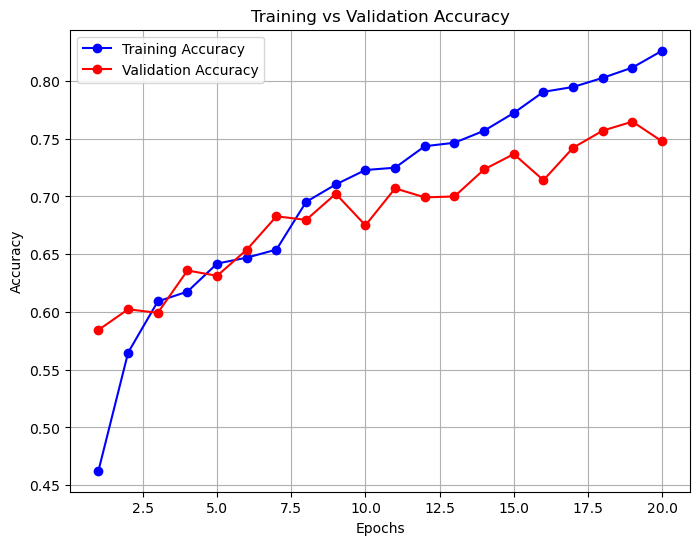

Test Accuracy: 0.7476562261581421


In [12]:
import matplotlib.pyplot as plt

# Data extracted from logs
epochs = list(range(1, 21))
accuracy = [
    0.4625, 0.5648, 0.6091, 0.6176, 0.6419, 0.6470, 0.6540, 0.6953, 0.7104, 
    0.7229, 0.7249, 0.7435, 0.7465, 0.7569, 0.7723, 0.7906, 0.7948, 0.8027, 
    0.8116, 0.8262
]
val_accuracy = [
    0.5844, 0.6023, 0.5992, 0.6359, 0.6313, 0.6539, 0.6828, 0.6797, 0.7023, 
    0.6750, 0.7070, 0.6992, 0.7000, 0.7234, 0.7367, 0.7141, 0.7422, 0.7570, 
    0.7648, 0.7477
]
test_accuracy = 0.7476562261581421  # Final test accuracy


# Plotting the training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, accuracy, label='Training Accuracy', marker='o', color='b')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o', color='r')

# Adding titles and labels
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

# Print Test Accuracy
print(f"Test Accuracy: {test_accuracy}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step


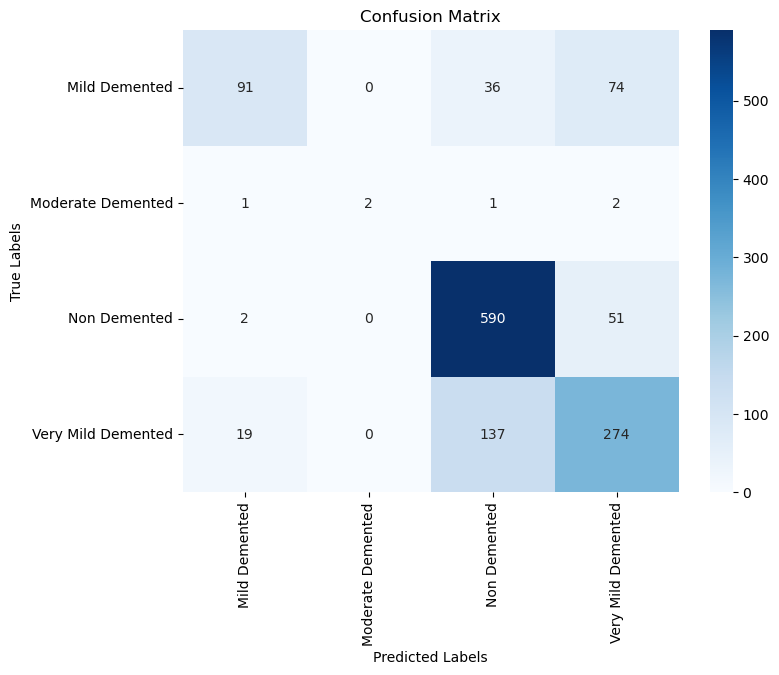

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.81      0.45      0.58       201
 Moderate Demented       1.00      0.33      0.50         6
      Non Demented       0.77      0.92      0.84       643
Very Mild Demented       0.68      0.64      0.66       430

          accuracy                           0.75      1280
         macro avg       0.82      0.59      0.64      1280
      weighted avg       0.75      0.75      0.74      1280



In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test)  # X_test is of shape (num_samples, 128, 128, 3)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Assume X contains image data and y contains labels
# Preprocessing the data
y_encoded = LabelEncoder().fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Load VGG16 with pre-trained ImageNet weights, exclude the top layer (classification layer)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the layers of the base model (you can unfreeze some layers for fine-tuning)
base_model.trainable = False

# Add custom layers on top of VGG16
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  # Global Average Pooling layer
x = layers.Dense(1024, activation='relu')(x)  # Fully connected layer
x = layers.Dropout(0.5)(x)  # Dropout layer to prevent overfitting
x = layers.Dense(y_categorical.shape[1], activation='softmax')(x)  # Output layer

# Create the final model
model = models.Model(inputs=base_model.input, outputs=x)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

# Evaluate the model
results = model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Accuracy: {results[1]}")


Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.4577 - loss: 1.1448 - val_accuracy: 0.5203 - val_loss: 1.0041
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.4833 - loss: 1.0531 - val_accuracy: 0.5148 - val_loss: 0.9789
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.5113 - loss: 1.0061 - val_accuracy: 0.5102 - val_loss: 0.9527
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.5393 - loss: 0.9695 - val_accuracy: 0.5203 - val_loss: 0.9450
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5472 - loss: 0.9462 - val_accuracy: 0.5359 - val_loss: 0.9344
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.5435 - loss: 0.9422 - val_accuracy: 0.5523 - val_loss: 0.9270
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5754 - loss: 0.9166 - val_accuracy: 0.5367 - val_loss: 0.9112
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5680 - loss: 0.9162 - val_accu

40/40 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step


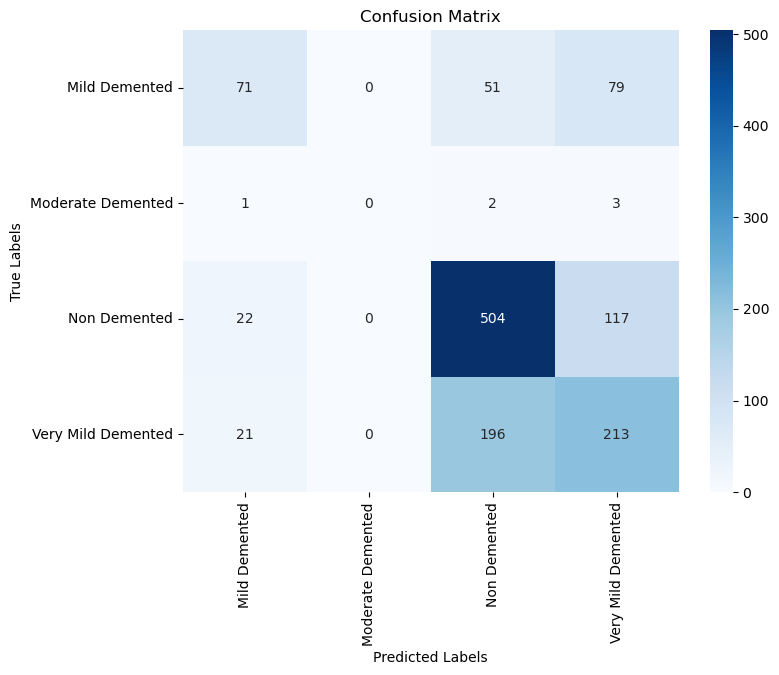

Classification Report:
                    precision    recall  f1-score   support

     Mild Demented       0.62      0.35      0.45       201
 Moderate Demented       0.00      0.00      0.00         6
      Non Demented       0.67      0.78      0.72       643
Very Mild Demented       0.52      0.50      0.51       430

          accuracy                           0.62      1280
         macro avg       0.45      0.41      0.42      1280
      weighted avg       0.61      0.62      0.60      1280



In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = model.predict(X_test)  # X_test is of shape (num_samples, 128, 128, 3)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoding to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
class_labels = ["Mild Demented", "Moderate Demented", "Non Demented", "Very Mild Demented"]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification Metrics
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


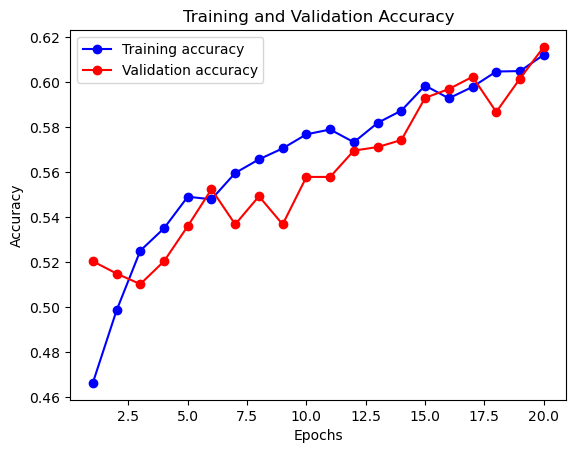

In [13]:
import matplotlib.pyplot as plt

# Assuming `history` is the history object returned by model.fit()
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)

# Plotting the accuracy
plt.plot(epochs, accuracy, 'b', label='Training accuracy',marker='o')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy',marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
